# EDA: repeat-purchase features

Run `python src/etl.py` first so `data/olist.db` exists and includes the
`order_reviews` / `products` tables this query needs.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2_contingency, spearmanr, ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor

DB_PATH = Path("../data/olist.db")
QUERY_PATH = Path("../queries/repeat_purchase_features.sql")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(QUERY_PATH.read_text(), conn, parse_dates=["first_order_date"])
conn.close()

print(f"{len(df):,} first-time customers (after the 3-month right-censoring cutoff)")
df.head()

83,644 first-time customers (after the 3-month right-censoring cutoff)


,customer_unique_id,customer_state,first_order_date,num_items,items_price,freight_value,product_category,payment_value,payment_installments,payment_type,review_score,review_delay_days,delivery_time_days,delivery_delay_days,repeat_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018-05-10 10:56:27,1,129.90,12.00,cama_mesa_banho,141.90,8.0,credit_card,5.0,0.132905,6.411227,-4.132905,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018-05-07 11:11:27,1,18.90,8.29,beleza_saude,27.19,1.0,credit_card,4.0,0.248125,3.285590,-4.248125,0
2,0000f46a3911fa3c0805444483337064,SC,2017-03-10 21:05:03,1,69.00,17.22,papelaria,86.22,8.0,credit_card,3.0,0.389734,25.731759,-1.389734,0
3,0000f6ccb0745a6a4b88665a16c9f078,PA,2017-10-12 20:29:41,1,25.99,17.63,telefonia,43.62,4.0,credit_card,4.0,0.108970,20.037083,-11.108970,0
4,0004aac84e0df4da2b147fca70cf8255,SP,2017-11-14 19:45:42,1,180.00,16.89,telefonia,196.89,6.0,credit_card,5.0,0.035463,13.141134,-7.035463,0


## 1. Class balance

The target is expected to be rare (the existing cohort-retention finding puts
month-1 retention under 1%). Confirm the actual rate here - this is what motivates
`class_weight="balanced"` and PR-AUC-over-accuracy in the modeling script.

repeat_purchase rate: 0.0331 (2,768 of 83,644)


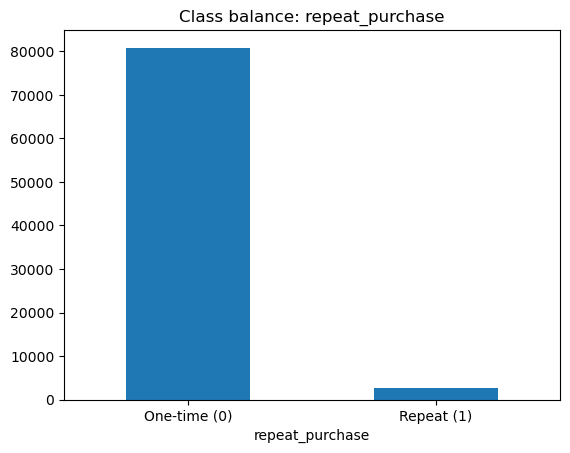

In [2]:
repeat_rate = df["repeat_purchase"].mean()
print(f"repeat_purchase rate: {repeat_rate:.4f} ({df['repeat_purchase'].sum():,} of {len(df):,})")

df["repeat_purchase"].value_counts().plot(kind="bar", title="Class balance: repeat_purchase")
plt.xticks([0, 1], ["One-time (0)", "Repeat (1)"], rotation=0)
plt.show()

## 2. Missingness per column

How much of each feature is actually missing? `review_score` is the one expected
to have real nulls - not every delivered order gets reviewed, and on top of that
the query's timing gate nulls out reviews that arrived too late to use (later
than 30 days after delivery.)
`review_delay_days` is null on the narrower condition of no review row at all.
Everything else should be close to complete given the query's joins.

In [3]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

product_category        1.483669
review_score            0.716130
review_delay_days       0.687437
payment_value           0.001196
payment_installments    0.001196
payment_type            0.001196
dtype: float64

## 6. Numeric feature distributions, split by target

Boxplots of each numeric feature for repeat vs. one-time customers - a first look
at which features might carry signal before the formal hypothesis tests / model.

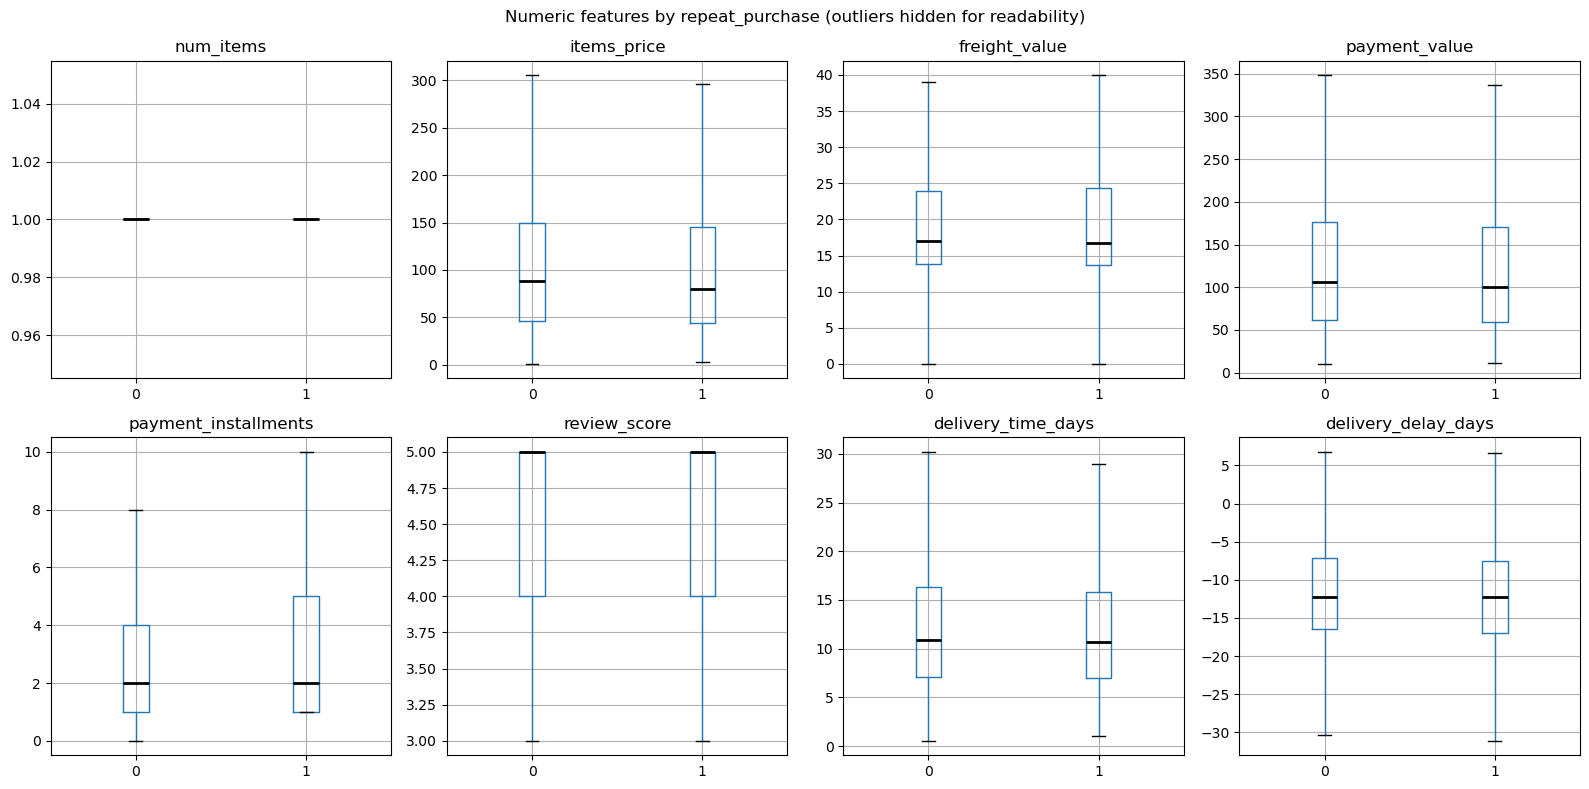

In [4]:
numeric_features = [
    "num_items", "items_price", "freight_value", "payment_value",
    "payment_installments", "review_score", "delivery_time_days", "delivery_delay_days",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_features):
    df.boxplot(
        column=col, by="repeat_purchase", ax=ax, showfliers=False,
        medianprops=dict(color="black", linewidth=2),
    )
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Numeric features by repeat_purchase (outliers hidden for readability)")
plt.tight_layout()
plt.show()

## 7. Repeat rate by categorical feature

Quick cut of repeat-purchase rate by `payment_type` and `product_category`
(top 10 by volume, to keep it readable) - feeds directly into the hypothesis
tests in `src/repeat_purchase_analysis.py`.

                  mean  count
payment_type                 
credit_card   0.033154  63190
boleto        0.032101  16822
voucher       0.040263   2583
debit_card    0.027672   1048



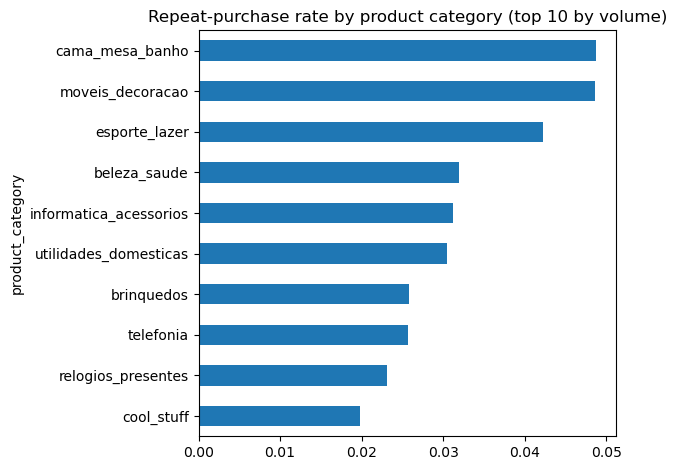

In [5]:
for col in ["payment_type"]:
    rates = df.groupby(col)["repeat_purchase"].agg(["mean", "count"]).sort_values("count", ascending=False)
    print(rates)
    print()

top_categories = df["product_category"].value_counts().head(10).index
cat_rates = (
    df[df["product_category"].isin(top_categories)]
    .groupby("product_category")["repeat_purchase"]
    .mean()
    .sort_values()
)
cat_rates.plot(kind="barh", title="Repeat-purchase rate by product category (top 10 by volume)")
plt.tight_layout()
plt.show()

## 9. Do delivery delays track the review score? (Spearman)

`review_score` is an ordinal 1-5 rating, so **Spearman** rank correlation is the
right test for a monotonic link with the two delivery-experience features:
`delivery_time_days` (purchase &rarr; delivery) and `delivery_delay_days`
(actual vs. promised delivery date; positive = late). Expectation: slower and
later deliveries pull the score down (negative rho), and the two delivery
features move together (positive rho). `review_score` is the leakage-gated
column, so pairs that involve it are computed on the rows with a usable review.

Spearman rho matrix:
                     review_score  delivery_delay_days  delivery_time_days
review_score                1.000               -0.193              -0.245
delivery_delay_days        -0.193                1.000               0.395
delivery_time_days         -0.245                0.395               1.000

Pairwise Spearman (rho, two-sided p, n):
         review_score vs delivery_delay_days  rho=-0.193  p=0.00e+00  n=83,045
         review_score vs delivery_time_days   rho=-0.245  p=0.00e+00  n=83,045
  delivery_delay_days vs delivery_time_days   rho=+0.395  p=0.00e+00  n=83,644


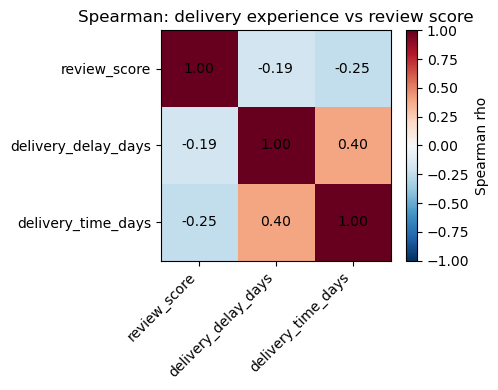

In [6]:
corr_cols = ["review_score", "delivery_delay_days", "delivery_time_days"]

# Spearman (rank) rather than Pearson: review_score is a 1-5 ordinal rating and
# any link with delivery speed is expected to be monotonic, not linear. pandas
# .corr does this pairwise-complete, so rows with no usable review_score are
# dropped only from the pairs that involve it.
spearman_rho = df[corr_cols].corr(method="spearman")
print("Spearman rho matrix:")
print(spearman_rho.round(3))

print("\nPairwise Spearman (rho, two-sided p, n):")
for a, b in [
    ("review_score", "delivery_delay_days"),
    ("review_score", "delivery_time_days"),
    ("delivery_delay_days", "delivery_time_days"),
]:
    pair = df[[a, b]].dropna()
    rho, p = spearmanr(pair[a], pair[b])
    print(f"  {a:>19} vs {b:<19}  rho={rho:+.3f}  p={p:.2e}  n={len(pair):,}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(spearman_rho, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{spearman_rho.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Spearman rho")
ax.set_title("Spearman: delivery experience vs review score")
plt.tight_layout()
plt.show()

## 10. Multicollinearity check: VIF

`src/repeat_purchase_analysis.py` reports logistic-regression **odds ratios** -
"a 1-point-higher review score multiplies repeat odds by X". Those per-feature
readings only hold if the features aren't proxies for each other:
`delivery_time_days` and `delivery_delay_days` both describe "how did delivery
go", and either can move with `review_score` (section 9). Strong collinearity
inflates the coefficients' standard errors and makes any single odds ratio
unreliable.

Variance Inflation Factor quantifies it: **VIF_i = 1 / (1 - R²_i)**, with R²_i
from regressing feature *i* on the other two. Rule of thumb: **> 5** is a
concern, **> 10** is serious. `review_score`'s nulls are median-filled first
(the same imputation the model pipeline applies) so the matrix is complete.

In [ ]:
vif_cols = ["review_score", "delivery_delay_days", "delivery_time_days"]

vif_X = df[vif_cols].copy()
# median-fill review_score (same imputation the model pipeline applies) so the
# design matrix is complete - VIF can't be computed with NaNs present.
vif_X["review_score"] = vif_X["review_score"].fillna(vif_X["review_score"].median())
vif_X = sm.add_constant(vif_X)  # VIF is defined relative to a model with an intercept

vif = pd.DataFrame({
    "feature": vif_X.columns,
    "VIF": [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])],
})
vif = vif[vif["feature"] != "const"]  # the intercept's own VIF is not meaningful
print(vif.to_string(index=False))

worst = vif["VIF"].max()
verdict = (
    "no multicollinearity concern"
    if worst < 5
    else "elevated"
    if worst < 10
    else "serious"
)
print(f"\nworst VIF = {worst:.2f}  ->  {verdict}")

            feature      VIF
       review_score 1.134827
delivery_delay_days 1.791239
 delivery_time_days 1.859593

worst VIF = 1.86  ->  no multicollinearity concern


: 

## Decisions from this notebook

- **"no usable review" as a feature** — RESOLVED: not used, and no longer emitted.
  `repeat_purchase_features.sql` gates `review_score` to reviews written before the
  customer's second order, so a review can only be gated out when a second order exists —
  i.e. the null-ness of `review_score` is itself partly a function of the target. A
  `review_missing` flag would leak that, so it was dropped from the query output
  (`BINARY_FEATURES = []` in `src/repeat_purchase_analysis.py`). `review_delay_days` stays
  in the output as an EDA diagnostic only.
- **review_score imputation** — median, applied in the model pipeline
  (`SimpleImputer(strategy="median")`). Known residual: ~1,036 fast-repeat customers whose
  review was gated out get pulled toward the median — an accepted limitation of keeping
  the second-order gate.
- **Odds-ratio validity** (section 10) — worst VIF among `review_score` /
  `delivery_delay_days` / `delivery_time_days` = **1.86** → no multicollinearity concern;
  these features' odds ratios are safe to read individually.
- **Outlier handling** before modeling (section 6) — `[fill in]`.